<a href="https://colab.research.google.com/github/mochaheree/heart_disease-portofolio/blob/main/notebook/02_python_exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.figure(figsize=(6,4))
sns.set_theme(style="whitegrid")

<Figure size 600x400 with 0 Axes>

In [3]:
df = pd.read_csv("/content/clean_final.csv")
df

,age,gender,blood_pressure,cholesterol_level,exercise_habits,smoking,family_heart_disease,diabetes,bmi,high_blood_pressure,...,sugar_consumption,triglyceride_level,fasting_blood_sugar,crp_level,homocysteine_level,heart_disease_status,age_group,risk_score_light,risk_segment,clinical_score
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,Medium,342.0,120.0,12.969246,12.387250,No,50-59,2,Medium,2
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,Medium,133.0,157.0,9.355389,19.298875,No,60-69,1,Low,2
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Low,393.0,92.0,12.709873,11.230926,No,40-49,2,Medium,2
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,High,293.0,94.0,12.509046,5.961958,No,30-39,3,Medium,2
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,High,263.0,154.0,10.381259,8.153887,No,60-69,4,High,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Medium,343.0,133.0,3.588814,19.132004,Yes,18-29,1,Low,2
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Low,377.0,83.0,2.658267,9.715709,Yes,30-39,0,Low,2
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Low,248.0,88.0,4.408867,9.492429,Yes,70 >,3,Medium,3
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Medium,113.0,153.0,7.215634,11.873486,Yes,18-29,3,Medium,3


In [9]:
target_col = "heart_disease_status"

t_counts = df[target_col].value_counts()
t_pct = df[target_col].value_counts(normalize=True)*100

display(pd.DataFrame({"Counts": t_counts, "Percentage": t_pct}))


,Counts,Percentage
heart_disease_status,,
No,8000,80.0
Yes,2000,20.0


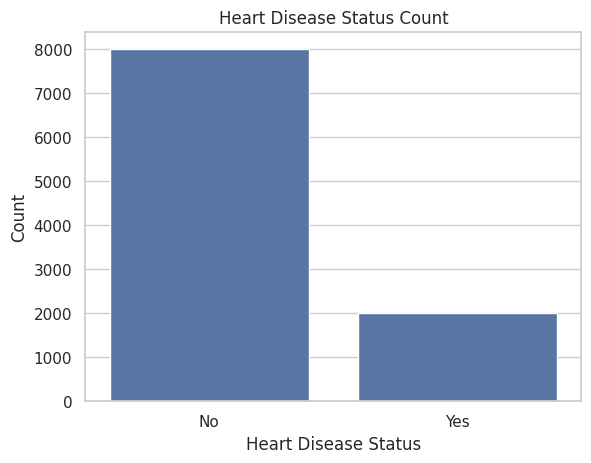

In [17]:
sns.countplot(data=df, x=target_col)
plt.title("Heart Disease Status Count")
plt.xlabel("Heart Disease Status")
plt.ylabel("Count")
plt.show()

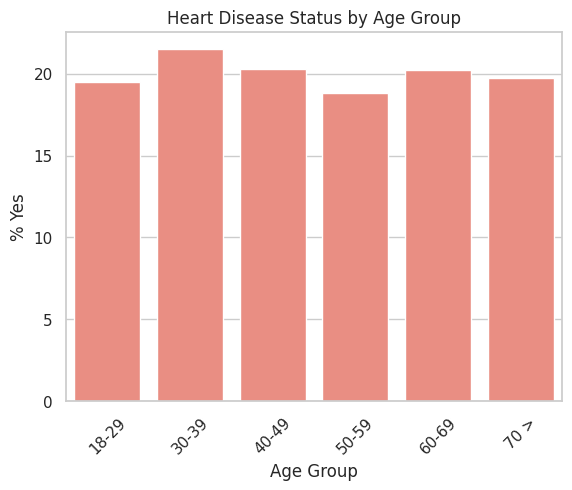

In [25]:
age_prev = pd.crosstab(df["age_group"], df[target_col], normalize="index")*100

sns.barplot(
    x=age_prev.index,
    y=age_prev["Yes"].values,
    color="salmon"
)

plt.title("Heart Disease Status by Age Group")
plt.xlabel("Age Group")
plt.ylabel("% Yes")
plt.xticks(rotation=45)
plt.show()

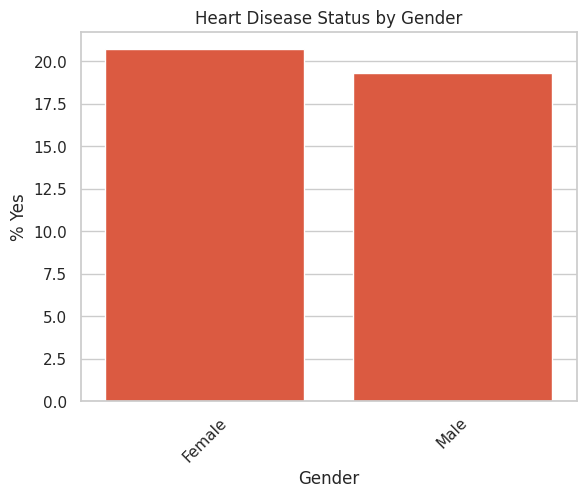

In [30]:
gender_prev = pd.crosstab(df["gender"], df[target_col], normalize="index")*100

sns.barplot(
    x=gender_prev.index,
    y=gender_prev["Yes"].values,
    color="#F54927"
)


plt.title("Heart Disease Status by Gender")
plt.xlabel("Gender")
plt.ylabel("% Yes")
plt.xticks(rotation=45)
plt.show()

In [46]:
target_col = "heart_disease_status"

num_cols = df.select_dtypes(include="number").columns.tolist()

gap_table = df.groupby(target_col)[num_cols].median().T
gap_table["abs_gap"] = (gap_table.iloc[:,0] - gap_table.iloc[:,1]).abs()
gap_table = gap_table.sort_values("abs_gap", ascending=False)

num_key = gap_table.index.tolist()
num_key


['blood_pressure',
 'bmi',
 'crp_level',
 'homocysteine_level',
 'sleep_hours',
 'cholesterol_level',
 'age',
 'fasting_blood_sugar',
 'triglyceride_level',
 'risk_score_light',
 'clinical_score']

In [38]:
summary_num = df.groupby(target_col)[num_key].agg(["mean"],"median")
summary_num

,blood_pressure,bmi,crp_level,homocysteine_level,sleep_hours,age,fasting_blood_sugar,cholesterol_level,risk_score_light,clinical_score
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
heart_disease_status,,,,,,,,,,
No,149.880,29.015276,7.485222,12.438250,6.994704,49.37925,120.168375,225.3685,2.244125,1.995875
Yes,149.271,29.325263,7.420114,12.527885,6.977979,48.96000,120.036000,225.6625,2.272500,1.998000


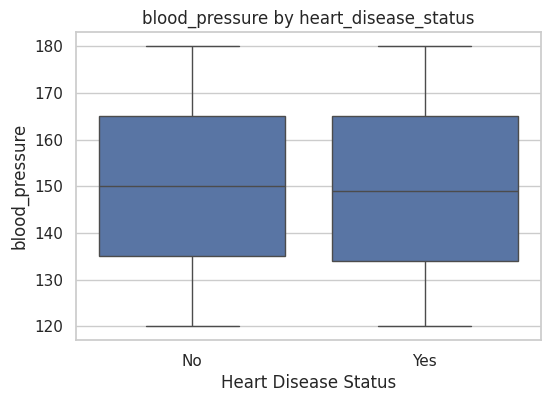

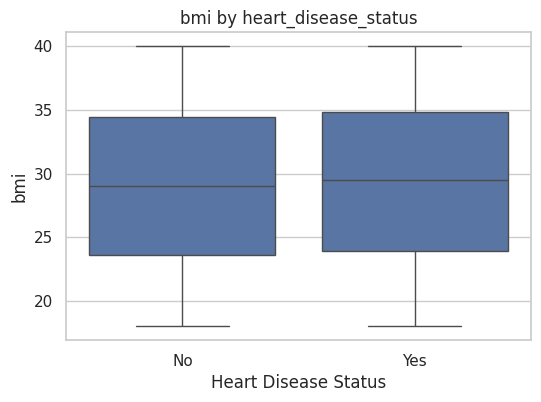

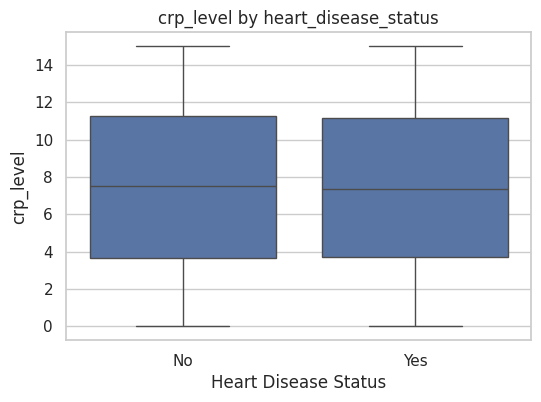

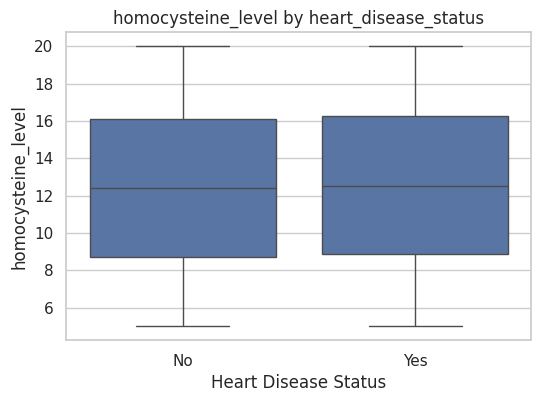

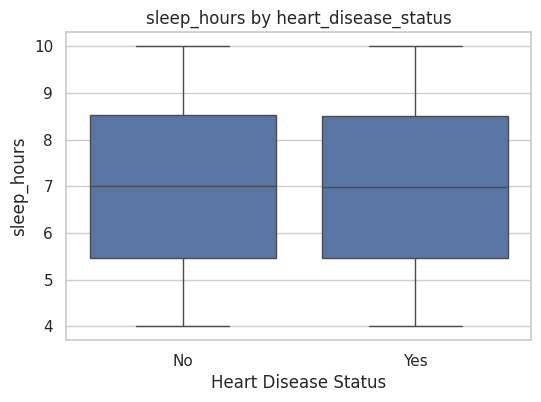

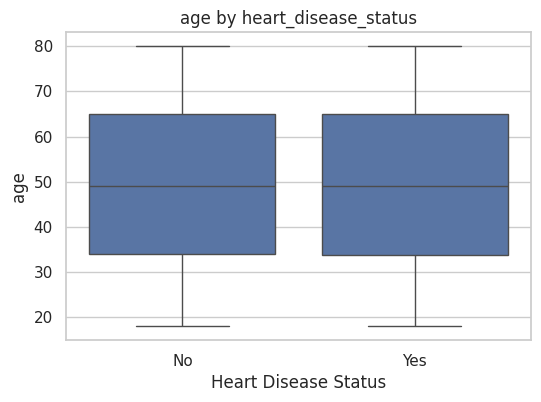

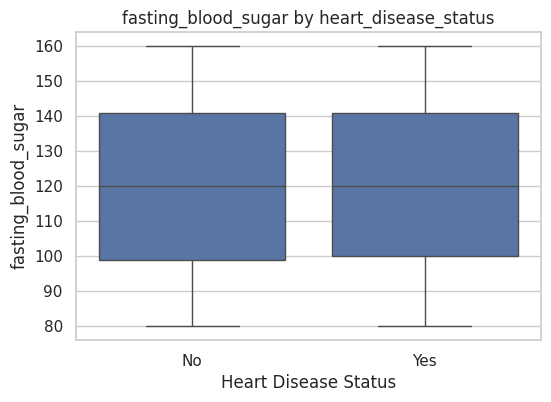

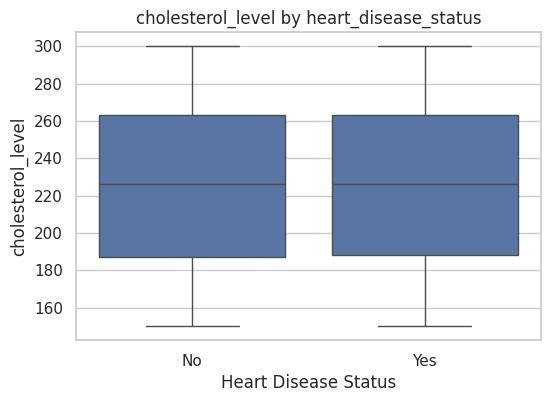

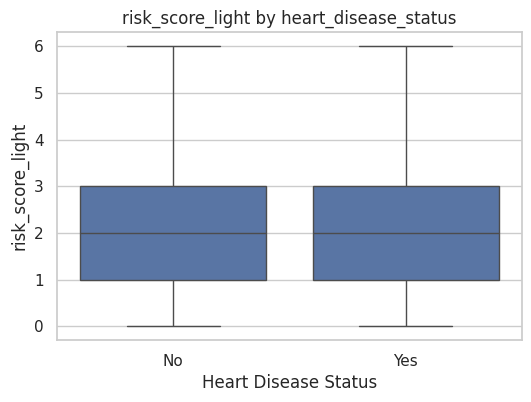

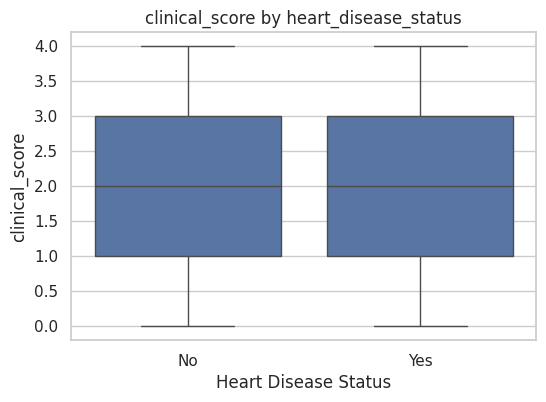

In [39]:
for col in num_key:
  plt.figure(figsize=(6,4))
  sns.boxplot(data=df, x=target_col, y=col)
  plt.title(f"{col} by {target_col}")
  plt.xlabel("Heart Disease Status")
  plt.ylabel(col)
  plt.show()


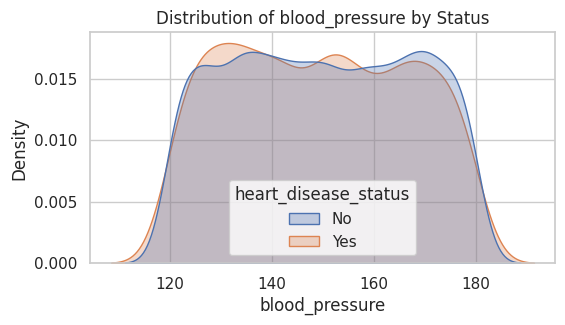

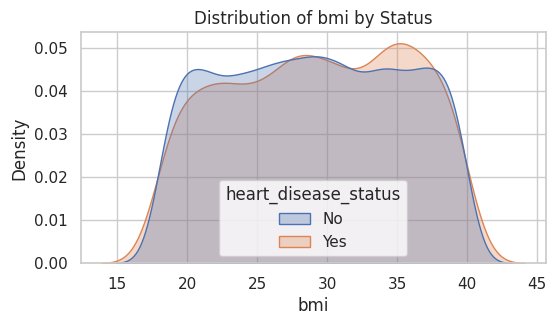

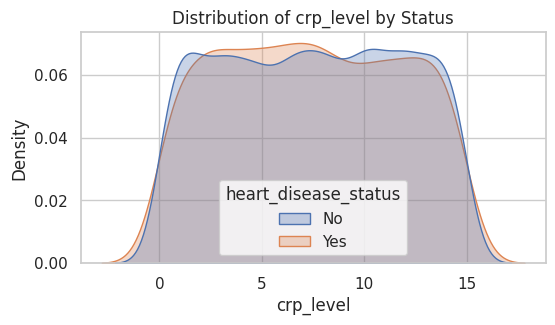

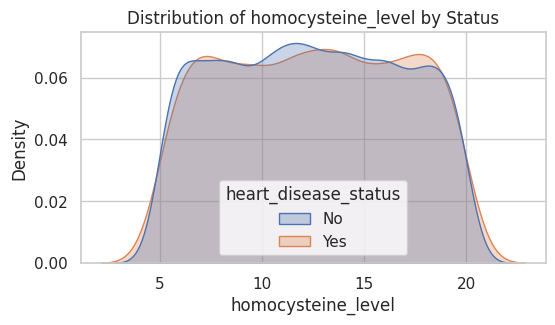

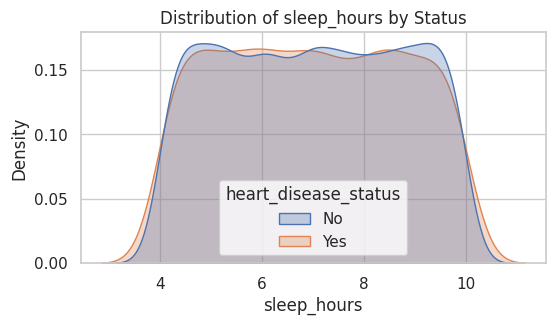

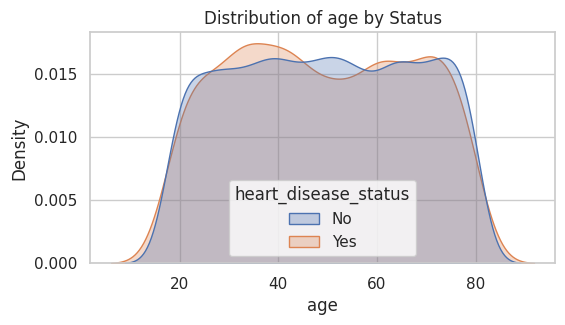

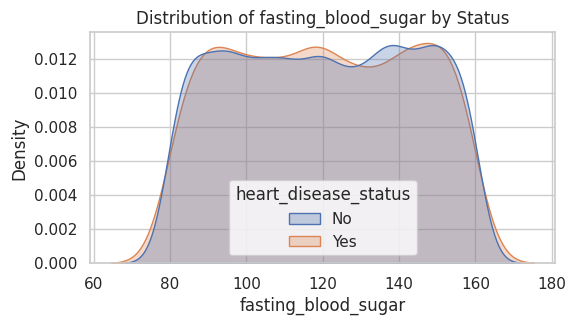

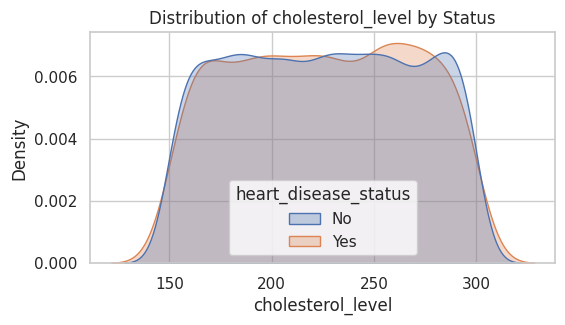

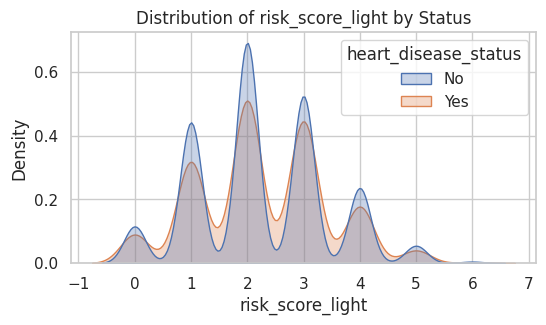

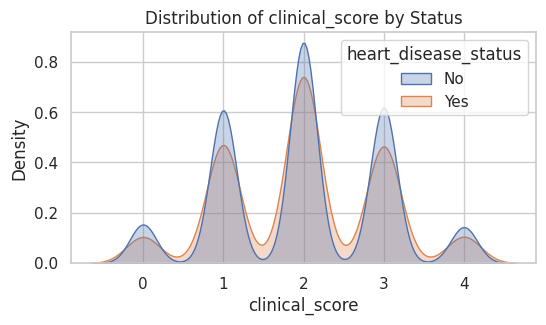

In [40]:
for col in num_key:
    plt.figure(figsize=(6,3))
    sns.kdeplot(data=df, x=col, hue=target_col, fill=True, common_norm=False, alpha=0.3)
    plt.title(f"Distribution of {col} by Status")
    plt.show()
